In [57]:
#===Libraries===

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn import svm

#Initial values
rng=np.random.default_rng(seed=42)
sample=200


In [12]:
#Motor States
#========================
#===  Healthy Motor   ===
#========================

norm_vib=rng.normal(loc=0.8, scale=0.01, size=sample)
norm_curr=rng.normal(loc=0.05, scale=0.01,size=sample)
norm_temp=rng.normal(loc=40, scale=2,size=sample)
norm_class=np.zeros(sample)






In [13]:

#===========================
#=== Mechanical Failure  ===
#===========================

#According to ISO Norm 10816
mech_vib=rng.normal(loc=4.5,scale=0.5,size=sample)
mech_curr=rng.normal(loc=0.06,scale=0.01,size=sample)
mech_temp=rng.normal(loc=40,scale=2,size=sample)
mech_class=np.ones(sample)

#===========================
#=== Electrical Failure  ===
#===========================

#According to IEEE
electr_vib=rng.normal(loc=0.9,scale=0.5,size=sample)
electr_curr=rng.normal(loc=1.25,scale=0.1,size=sample)
electr_temp=rng.normal(loc=68,scale=4,size=sample)
electr_class=np.ones(sample)*2








In [ ]:
#Data concatanation
tot_vib=np.concatenate((norm_vib,mech_vib,electr_vib))
tot_curr=np.concatenate((norm_curr,mech_curr,electr_curr))
tot_temp=np.concatenate((norm_temp,mech_temp,electr_temp))
tot_class=np.concatenate((norm_class,mech_class,electr_class))


#Feature Fusion
dataframe=pd.DataFrame({"RMS_Vibration":tot_vib,
                       "MCSA Current":tot_curr,
                        "Temperature":tot_temp,
                        "Motor State":tot_class
                       })
dataframe.head()
print("\nCantidad de muestras por estado del motor:")
print(dataframe["Motor State"].value_counts())

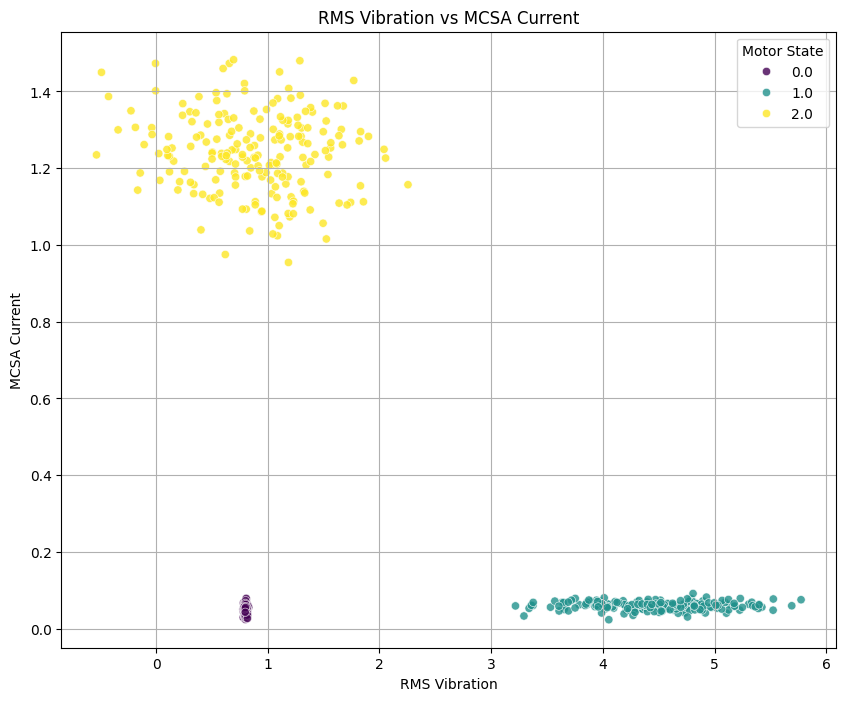

In [26]:
#Data Plot
plt.figure(figsize=(10,8))
sns.scatterplot(dataframe,x="RMS_Vibration",y="MCSA Current",hue="Motor State",palette="viridis",alpha=0.8)
plt.title("RMS Vibration vs MCSA Current")
plt.xlabel("RMS Vibration")
plt.ylabel("MCSA Current")
plt.grid(True)
plt.show()

In [29]:
#AI Training
X=dataframe.drop(columns=["Motor State"])
y=dataframe["Motor State"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


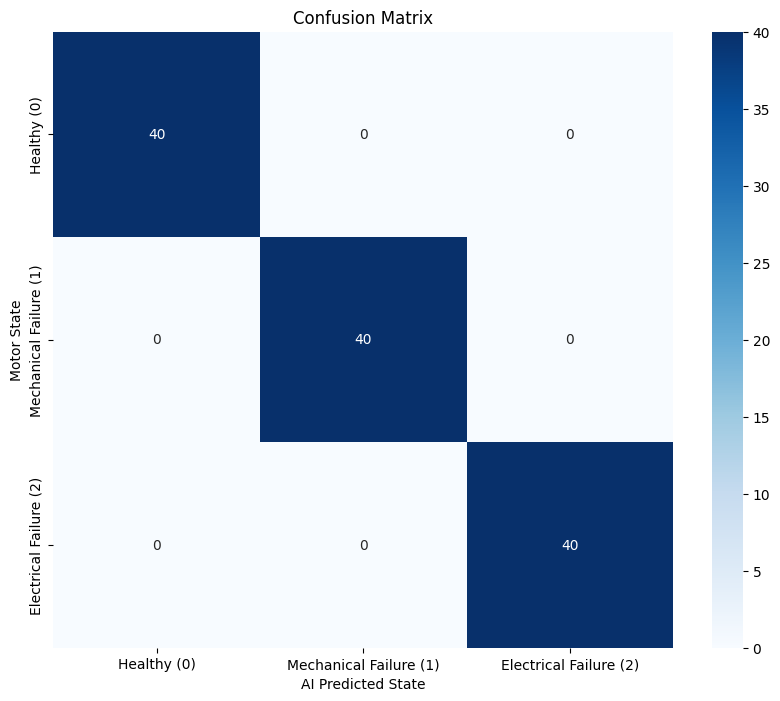

MODEL PERFORMANCE METRICS
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        40
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [36]:
#===============================
#===== Random Forest Model  ====#
#===============================

rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
predictions=rf_model.predict(X_test)

#Matriz de confusión
matrix=confusion_matrix(y_test,predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',xticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"],yticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"])
plt.title("Confusion Matrix")
plt.xlabel("AI Predicted State")
plt.ylabel("Motor State")
plt.show()

print("MODEL PERFORMANCE METRICS")
print(classification_report(y_test,predictions))

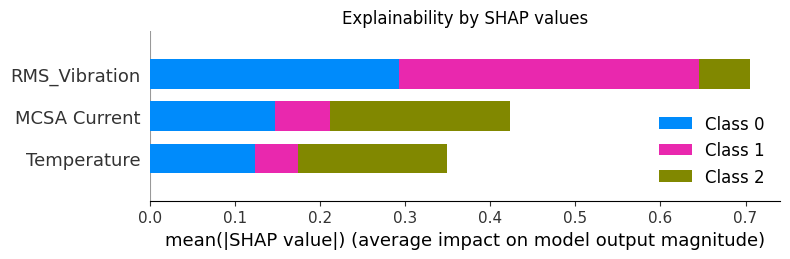

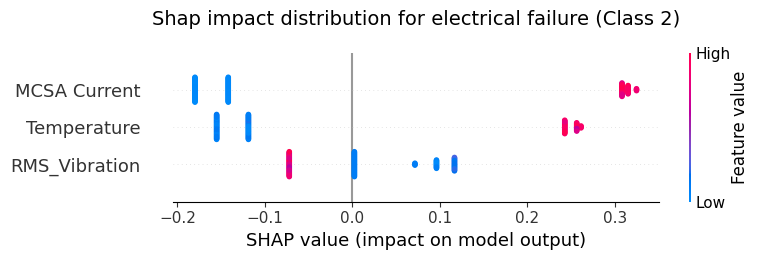

Indexes for Motor electrical failure in y_test:
[422, 461, 447, 580, 526]


<Figure size 1200x400 with 0 Axes>

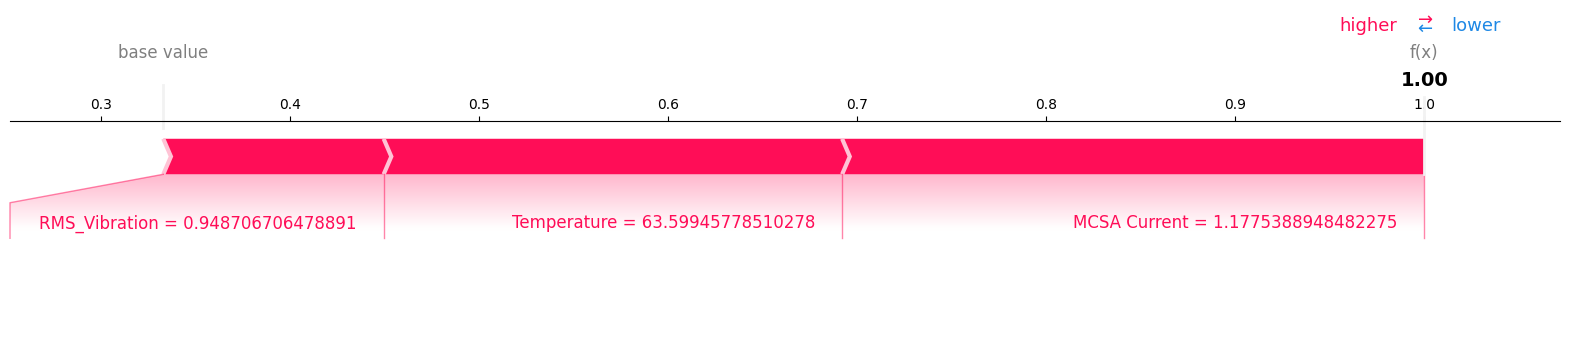

In [56]:
#Shap Explanation for Random Forest Model


#SHAP General Overview
shap_explainer=shap.TreeExplainer(rf_model)
shap_values=shap_explainer.shap_values(X_test)
plt.figure(figsize=(6,4))
plt.title("Explainability by SHAP values")
shap.summary_plot(shap_values,X_test,plot_type="bar",show=False)
plt.tight_layout()
plt.show()



#SHAP Beesharm Plot

obj_electric_explainer = shap.Explanation(
    values=shap_values[:, :, 2],
    data=X_test,
    feature_names=X_test.columns
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(obj_electric_explainer, max_display=3, show=False)
plt.title("Shap impact distribution for electrical failure (Class 2)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#SHAP Force Plot

#Index searching for an electric failure case
index_electric_fail = y_test[y_test == 2].index
print("Indexes for Motor electrical failure in y_test:")
print(list(index_electric_fail)[:5])



shap.initjs()


chosen_index = index_electric_fail[1]

position_in_test = X_test.index.get_loc(chosen_index)

obj_Ele_fail = shap.Explanation(
    values=shap_values[position_in_test, :, 2],
    base_values=shap_explainer.expected_value[2],
    data=X_test.iloc[position_in_test],
    feature_names=X_test.columns
)

# Force Plot Creation
plt.figure(figsize=(12, 4))
shap.plots.force(obj_Ele_fail, matplotlib=True)

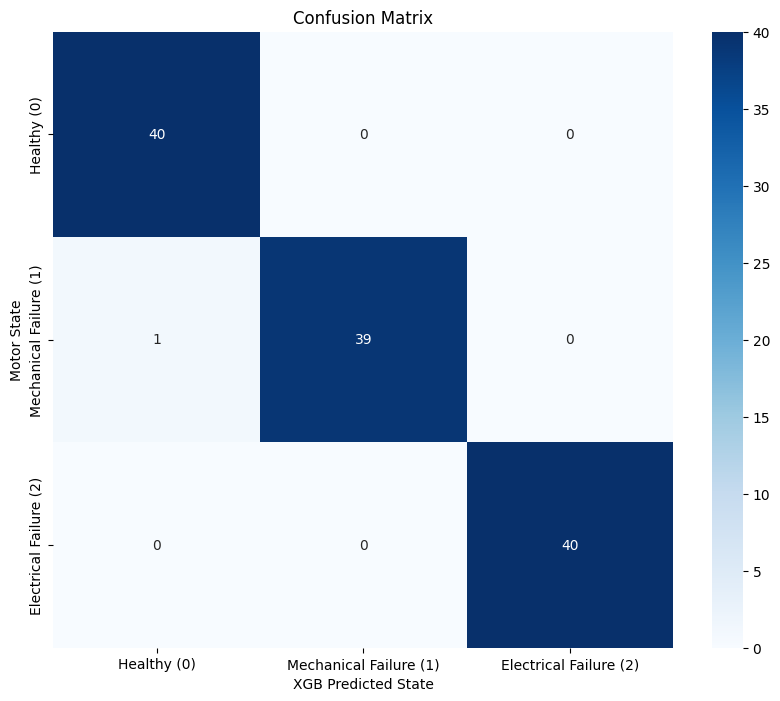

MODEL PERFORMANCE METRICS
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        40
         1.0       1.00      0.97      0.99        40
         2.0       1.00      1.00      1.00        40

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [62]:
#===============================
#===== XGBoost AI Model     ====
#===============================

model_xgb=XGBClassifier(n_estimators=100, random_state=42)
model_xgb.fit(X_train,y_train)
predictions_xgb=model_xgb.predict(X_test)
matrix=confusion_matrix(y_test,predictions_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',xticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"],yticklabels= ["Healthy (0)","Mechanical Failure (1)", "Electrical Failure (2)"])
plt.title("Confusion Matrix")
plt.xlabel("XGB Predicted State")
plt.ylabel("Motor State")
plt.show()

print("MODEL PERFORMANCE METRICS")
print(classification_report(y_test,predictions_xgb))





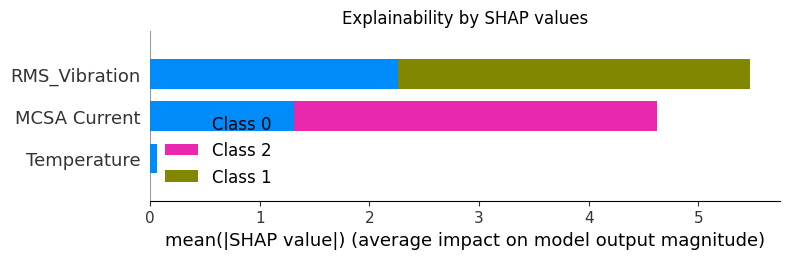

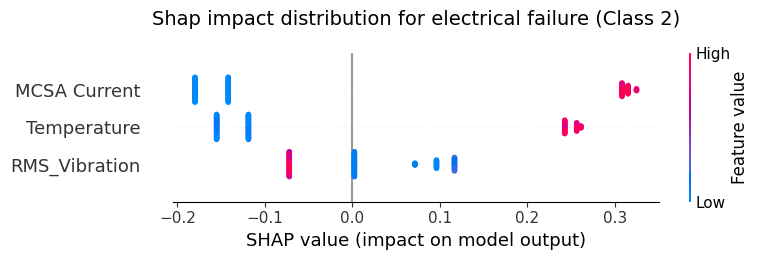

Indexes for Motor electrical failure in y_test:
[422, 461, 447, 580, 526]


/usr/local/lib/python3.12/dist-packages/shap/plots/_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


<Figure size 1200x400 with 0 Axes>

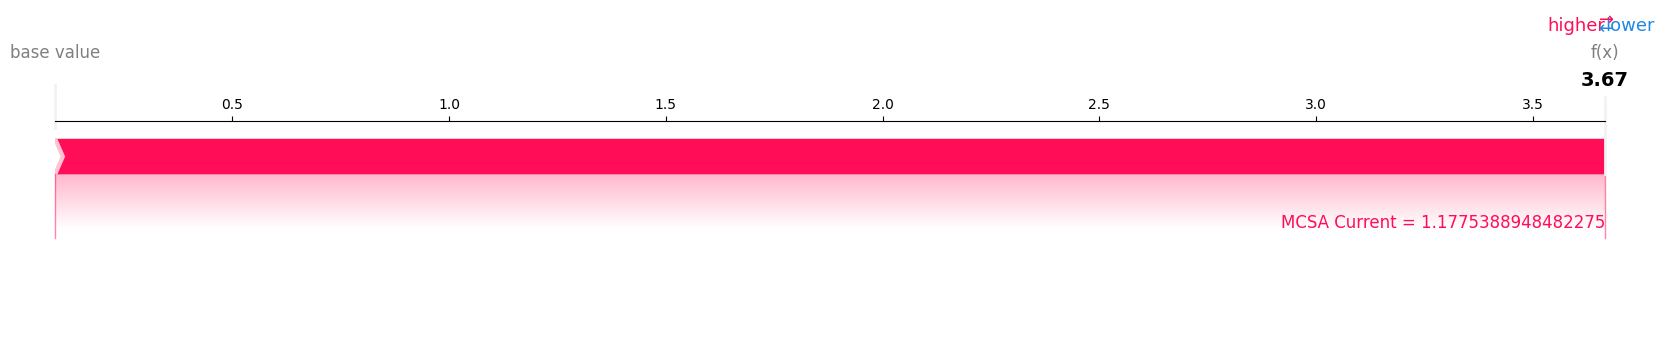

In [67]:
#Shap Explanation for XGBoost Model
shap_explainer_xgb=shap.TreeExplainer(model_xgb)
shap_values_xgb=shap_explainer_xgb.shap_values(X_test)
plt.figure(figsize=(6,4))
plt.title("Explainability by SHAP values")
shap.summary_plot(shap_values_xgb,X_test,plot_type="bar",show=False)
plt.tight_layout()
plt.show()

#SHAP Beesharm Plot

obj_electricxgb_explainer = shap.Explanation(
    values=shap_values[:, :, 2],
    data=X_test,
    feature_names=X_test.columns
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(obj_electricxgb_explainer, max_display=3, show=False)
plt.title("Shap impact distribution for electrical failure (Class 2)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#SHAP Force Plot

#Index searching for an electric failure case
index_electric_fail = y_test[y_test == 2].index
print("Indexes for Motor electrical failure in y_test:")
print(list(index_electric_fail)[:5])



shap.initjs()


chosen_index = index_electric_fail[1]

position_in_test = X_test.index.get_loc(chosen_index)

obj_Ele_fail_xgb = shap.Explanation(
    values=shap_values_xgb[position_in_test, :, 2],
    base_values=shap_explainer_xgb.expected_value[2],
    data=X_test.iloc[position_in_test],
    feature_names=X_test.columns
)

# Force Plot Creation
plt.figure(figsize=(12, 4))
shap.plots.force(obj_Ele_fail_xgb, matplotlib=True)